## Lab 5: Model Evaluation in Classification with Breast Cancer Dataset

In this lab you will be focusing on model evaluation using a larger dataset, specifically the famous Breast Cancer Wisconsin (Diagnostic) dataset, found on scikit-learn dataset reporistory. This dataset contains features computed from a digitized image of a fine needle aspirate (FNA) of a breast mass, and the target variable indicates whether the mass is benign or malignant.

### Objective:

In this lab, you will evaluate the performance of different classification models using various evaluation metrics and techniques on the Breast Cancer Wisconsin (Diagnostic) dataset. The classification models that you will look for are: Support Vector Machines (SVM), Random Forest and Gradient Boosting. The tasks involved are:

#### 1) Load the Breast Cancer dataset

Load the nessecary python libabries and the breast cancer dataset (the name of the dataset from scikit-learn is: <code>load_breast_cancer</code>). Select also data and train targets.


In [25]:
import numpy as np # for numerical calculations
import pandas as pd # dataframe
from sklearn.datasets import load_breast_cancer # sklearn buitl in datasets....
from sklearn.model_selection import train_test_split, cross_validate # mdel selectnio for cross valdiation, splitting and tes6ogm of dataset
from sklearn.svm import SVC # SVC willbe one models we will evaluate today
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier # along with models RF classifier
# in ensembles one
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
#  for scores and comparison
import matplotlib.pyplot as plt #visualisations

# Step 1: Load the Breast Cancer dataset
data = load_breast_cancer()
# whe have built in dataset can etrieve them without known the names of the columns
# don't need details of target features etc as buitlt in data
# cancerous vs non-cancerous
# both are arrays
X = data.data # 2 D array of features - 30 features per sample
y = data.target #  1D array of labels (0=malignant ans 1 = benign)

#### 2) Preprocess the data (if necessary).

Perform an initial analysis of the daatset! If the data quaility is fine (no missing data etc.) You cna skip this step. 

- This data set is clean : no missing values, numeric features only

- SCaling may help SVM, but Random Forest and Gradient Boosting don't require scaling
-
- check if an missing features / values... 

In [26]:
# X.shape
# y.shape
# checks for missing values within the dataset
# convert numpy array into a dataframe - returns true/false for every cell (True is missing (NaN)
# sums each column -counts missing values per column
# sums all those column totals - gives one number...
# output is zero so good to go...
# all features important  - no need to drop any features....
print(pd.DataFrame(X).isnull().sum().sum())

0


#### 3) Split the data into training and testing sets.

Try the split ratio of 80/20. Check and printout the output shapes after the split. 

In [27]:
# 80 = testing
# 20 = testing
# training data for X and y should have the same number....
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(455, 30) (114, 30) (455,) (114,)


#### 4) Train multiple classification models

The models that should be trained are: 

<ul>
<li>Support Vector Machine (SVM)</li>
<li>Random Forest</li>
<li>Gradient Boosting</li>
</ul>

Consider defining and using a pipeline of models and train them through the pipeline. 

In [28]:
# create an instance for each class of the clasifiers...
# SVM = is equal true  >> will be iportant for ROC curve calculation
# RF = 
# GB = 
# creat a dictinoary that will define three models
models = {
    'Support Vector Machine': SVC(probability=True),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier()
}

# train using training data that we have
# use a for loop to loop through the dictionary...
# train 3 models using traingi data and use .fit
# very useful to tarin them in one lien of code...
for name, model in models.items():
    model.fit(X_train, y_train)

#### 5) Evaluate the models using the following evaluation metrics:
<ul>
<li>Accuracy</li>
<li>Precision</li>
<li>Recall</li>
<li>F1 Score</li>
<li>ROC-AUC Score</li>
</ul>

In [ ]:
# 5 evaluation metrics...
# accuracy = overall correct predictions over predicted decicions
# precision = correct positive predictions over totla predicted positives
# recall  = (also called sensitivity) = this is correct positive predicytsuib / actual posisitves
# F1 score = harmonic mean between precision and recall -can be used for handlign imbalanced data
# ROC = area under curve - shows model ability to separate classes that we have in our dataset...
# create a dictionary 
metrics = {
    'Accuracy': accuracy_score,
    'Precision': precision_score,
    'Recall': recall_score,
    'F1 Score': f1_score,
    'ROC-AUC Score': roc_auc_score
}

for name, model in models.items():
    # print the name of the model - if don't print them will nto knwo which belngs to which classifier
    print(f"Evaluation metrics for {name}:")
    # predict what si output of features of your testing y_predict  = predicted values
    y_pred = model.predict(X_test)
    # testing the models...
    # lop thru each metric
    for metric_name, metric_func in metrics.items():
        # compute the score for each metrics.. pas to y_test  = actual value predicted value
        # y_tes and Y_predict for each model...
        # call the metric function
        score = metric_func(y_test, y_pred)
        # print name of m etric that you aer evaluatig and then the score...
        print(f"{metric_name}: {score}")
        # just a break line between each classifier...
    print()
    
#  it's a **loop within a loop**:
# - Outer loop → each model (SVC, Random Forest, Gradient Boosting)
# - Inner loop → each metric applied to that model's predictions

# The key line is `metric_func(y_test, y_pred)` — every sklearn metric function takes the same two arguments (actual values, predicted values), which is exactly why storing them in a dictionary like this works so cleanly.

Evaluation metrics for Support Vector Machine:
Accuracy: 0.9473684210526315
Precision: 0.922077922077922
Recall: 1.0
F1 Score: 0.9594594594594594
ROC-AUC Score: 0.9302325581395349

Evaluation metrics for Random Forest:
Accuracy: 0.956140350877193
Precision: 0.9583333333333334
Recall: 0.971830985915493
F1 Score: 0.965034965034965
ROC-AUC Score: 0.9510317720275139

Evaluation metrics for Gradient Boosting:
Accuracy: 0.956140350877193
Precision: 0.9583333333333334
Recall: 0.971830985915493
F1 Score: 0.965034965034965
ROC-AUC Score: 0.9510317720275139



In [33]:
# as RF and GB have idential resutls we will do cross-validation to see if they diverge see if that is a red flag 
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='f1')
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

Support Vector Machine: 0.9339 (+/- 0.0249)
Random Forest: 0.9707 (+/- 0.0196)
Gradient Boosting: 0.9707 (+/- 0.0163)


#### 6) Compare the model performance metrics

Which of the models perform better? Which of these metrics would you trust the most? Why?

**cancer scenario**

- recall and F1 will eb better option of measrure than the others....
- focussing on Recall = > choose SVM >> has a value of 1.0.. perfect score...
- Focussing on F1 score = >> choose RF
- if check Gradient - will nto find there is nay values higher than the other two...
- really depend on application using 


=======
SVM stands out with Recall = 1.0
- It correctly identified every single cancer case (no false negatives)
- But lower Precision (0.92) means it flagged some healthy patients as cancerous
- For cancer diagnosis this is actually the preferred trade-off — missing a cancer case is far worse than a false alarm
- Lower ROC-AUC (0.93) despite perfect recall suggests it's being quite aggressive in predicting positive


Random Forest and Gradient Boosting are identical here
- Same scores across every metric — this can happen with small test sets (114 samples)
- Both are more balanced between precision and recall than SVM
- Slightly higher overall accuracy than SVM

#### 7) Plot the ROC curves for each model

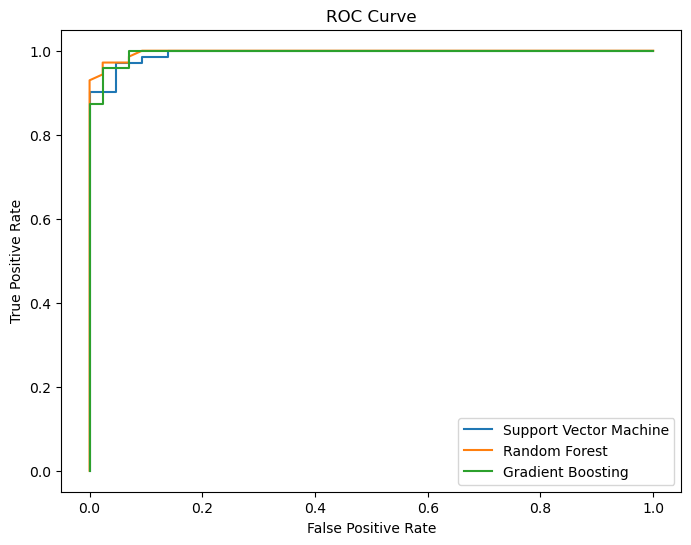

In [ ]:
plt.figure(figsize=(8, 6))
for name, model in models.items():
    # all samples except the last one
    y_proba = model.predict_proba(X_test)[:, 1]
    # tpr = true positive rate
    # fpr  = false positive rate
    # y_probab ?
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=name)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

result of plot - plot of all three shows a trade fof between sensitivity and specificity (based on FP and TP)
curve nearer to top left is the better model

#### 8) Evaluate with Cross-validation

Repeat steps 4) - 7) using 10-fold cross validation during model training instead of simple holdout method. What is the difference? Why is that?


In [ ]:
# Step 4: Initialize multiple classification models
models = {
    'Support Vector Machine': SVC(probability=True),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier()
}

# Step 5: Evaluate the models using 10-fold cross-validation
metrics = {
    'Accuracy': 'accuracy',
    'Precision': 'precision',
    'Recall': 'recall',
    'F1 Score': 'f1',
    'ROC-AUC Score': 'roc_auc'
}

for name, model in models.items():
    print(f"Evaluation metrics for {name}:")
    # cv is number of whole that wneed to apply to them for the data that we have?
    cv_results = cross_validate(model, X, y, cv=10, scoring=metrics)
    # lop for each fold that we have inside the data...
    for metric_name, scores in cv_results.items():
        # print an average for each value that w ehave...
        # apply numpy .mean to get average of performance metrics...
        # value of average accuracy across the 10 folds that we have...
        # get standard deviations in accuracy scor across the 10o folds we have...
        print(f"{metric_name}: {np.mean(scores):.2f} (+/- {np.std(scores):.2f})")
    print()

Evaluation metrics for Support Vector Machine:
fit_time: 0.08 (+/- 0.02)
score_time: 0.05 (+/- 0.02)
test_Accuracy: 0.91 (+/- 0.03)
test_Precision: 0.90 (+/- 0.04)
test_Recall: 0.98 (+/- 0.02)
test_F1 Score: 0.93 (+/- 0.02)
test_ROC-AUC Score: 0.98 (+/- 0.01)

Evaluation metrics for Random Forest:
fit_time: 0.63 (+/- 0.26)
score_time: 0.06 (+/- 0.03)
test_Accuracy: 0.96 (+/- 0.04)
test_Precision: 0.97 (+/- 0.04)
test_Recall: 0.97 (+/- 0.03)
test_F1 Score: 0.97 (+/- 0.03)
test_ROC-AUC Score: 0.99 (+/- 0.02)

Evaluation metrics for Gradient Boosting:
fit_time: 1.42 (+/- 0.30)
score_time: 0.03 (+/- 0.01)
test_Accuracy: 0.96 (+/- 0.03)
test_Precision: 0.96 (+/- 0.03)
test_Recall: 0.98 (+/- 0.02)
test_F1 Score: 0.97 (+/- 0.02)
test_ROC-AUC Score: 0.99 (+/- 0.01)



- fit time  = training time...
- score time = testing time

have accuracy  = 0.91 +0.3 (acuracy and standard deviation of the accuracy)

check the f1 score  >> 93 >> 97 >>> 97
if focussing on F1 score choose betwene RF and GB classifier

if you checlk recallfor SVM while using 80/20 ... earlier... btu here differnt splitting methods affectt he performance of the model
10 fold is better than traditional traigin / testing

========
cross_validate vs cross_val_score

- cross_validate is more powerful — it runs multiple metrics at once and also returns fit_time and score_time
- That's why you're seeing fit_time and score_time in the output — they come automatically and aren't metrics you asked for
c- v=10 means 10-fold cross validation (more reliable than the 5-fold used earlier) 


====
Interpreting the results:
- SVM is now clearly the weakest
- Accuracy only 0.91 vs 0.96 for both others
- High Recall (0.98) still — confirms it's aggressive at catching positives
- But ROC-AUC of 0.98 is actually strong — better than its F1 suggests


=======
Notable practical observations:

- fit_time shows Gradient Boosting (1.42s) is 18x slower to train than SVM (0.08s) — relevant for large datasets
- Random Forest (0.63s) is a good middle ground
- score_time is fast for all three — predicting is cheap once trained

Overall verdict — 
- RF and GB are both excellent, with GB being marginally more stable (lower variance on most metrics). 
- But given GB is significantly slower to train with no meaningful accuracy gain, Random Forest is the most practical choice here

#### Bonus Task

Try other validation methods such as Bootstrapping. See how you cna implemnt that in scikit-learn. 

In [34]:
from sklearn.utils import resample # built in 

n_iterations = 200  # lecture recommended >= 200
bootstrap_scores = {name: [] for name in models.keys()}

for i in range(n_iterations):
    # resample with replacement - this is what makes it bootstrapping
    X_boot, y_boot = resample(X, y, random_state=i)
    
    # out-of-bag samples (samples not selected) used for testing
    # find indices not selected in the bootstrap sample
    oob_indices = [i for i in range(len(X)) if i not in resample(
        range(len(X)), random_state=i)]
    X_test_oob = X[oob_indices]
    y_test_oob = y[oob_indices]
    
    for name, model in models.items():
        model.fit(X_boot, y_boot)
        score = f1_score(y_test_oob, model.predict(X_test_oob))
        bootstrap_scores[name].append(score)

# print results
for name, scores in bootstrap_scores.items():
    print(f"{name}:")
    print(f"  F1: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")

Support Vector Machine:
  F1: 0.9143 (+/- 0.0053)
Random Forest:
  F1: 0.9853 (+/- 0.0067)
Gradient Boosting:
  F1: 0.9839 (+/- 0.0089)


Key concepts:
- resample(...) — samples the data with replacement, meaning the same sample can be picked multiple times. This is what defines bootstrapping.
- Out-of-bag (OOB) samples — the samples that were NOT selected in the bootstrap become the test set. On average about 37% of samples are left out each iteration, which is why it works even on small datasets



**When to use each method — from your lecture:**
- Dataset Size        Method
- < 300 samples =     Bootstrapping
- Medium        =     Cross-Validation
- Very large    =     Holdout

The breast cancer dataset (569 samples) is borderline — cross-validation is fine here, but bootstrapping is good to know for smaller real-world datasets.

**Holdout**

- Simply split your data into fixed chunks — typically 80% train, 20% test
- Train on one chunk, test on the other, done
- Fast but can get "lucky" or "unlucky" depending on how the split falls


**Bootstrapping**

- Repeatedly sample your data with replacement (same sample can appear multiple times)
- Each iteration ~63% of data used for training, the leftover ~37% used for testing
- Repeat 200+ times and average the results
- Preferred for small datasets because you're squeezing more signal out of limited data


**Simple analogy:**

- Holdout = cut a deck of cards once and play with what you get
- Bootstrapping = repeatedly shuffle and redeal 200 times, average your hand quality across all deals — much more reliable picture

